# Proceso de desarrollo para proceso de CSV

Dado el desarrollo de mi proyecto y debido a que mi ase tiene vaores Nan, y el registro historioco se basa desde 2005, usare un desarrollo clasico para limpiar los datis y lograr extraes el promedio de afluencia por linea de año reciente

# modulo de importacion de librerias

> Dj al habla, por orden acomodare para su facil ejecucion de manera global eh independiente con este formato

In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import circuit_drawer

In [ ]:
csv = "./data/afluenciamb_simple_05_2026.csv"

df = pd.read_csv(csv)

df['afluencia'] = pd.to_numeric(df['afluencia'], errors='coerce')
df = df.dropna(subset=['afluencia'])

anio_reciente = df['anio'].max()
df_filtrado = df[df['anio'] == anio_reciente]

lineas_objetivo = ['Línea 1', 'Línea 2','Línea 3','Línea 4']
afluencias_promedio = {}

for line in lineas_objetivo :
    promedio = df_filtrado[df_filtrado['linea'] == line]['afluencia'].mean()
    afluencias_promedio[line] = promedio if not np.isnan(promedio) else 1.0


base_costos_geograficos = np.array([
    [10, 25, 15, 30],
    [20, 12, 10, 15],
    [30, 15, 25, 10],
    [15, 20, 20, 25]
])

max_afluencia = max(afluencias_promedio.values())
factores_demanda = np.array([afluencias_promedio[l] / max_afluencia for l in lineas_objetivo])

S = base_costos_geograficos / factores_demanda
S = np.round(S, 2)

print("Matriz S de Costos Operacionales 4x4 generada:")
print(S)

# Modelado Qubo 

Este fragmento toma la matriz de afluencia $ S $ , expande algebraicamente las penalizaciones cuanticas y construye el diccionario QUBO compatible con resolvedores locales

In [ ]:
S = np.array([
    [ 10.0, 56.56, 37.5, 150.68],
    [ 20.0, 27.15, 25.03, 75.34],
    [ 30.0, 33.94, 62.58, 50.23],
    [ 15.0, 45.25, 50.07, 125.57]
])
N = 4
P = 5 * np.max(S)

Q = np.zeros((N * N , N * N))

def Costo_matriz_S():
    for i in range(N):
        for j in range(N):
            idx = i * N + j
            Q[idx, idx] += S[i, j]

def Restriccion_filas():
    for i in range(N):
        for j in range(N):
            idix1 = i * N + j
            Q[idix1, idix1] -= P
            for k in range(j + 1, N):
                idix2 = i * N + k
                Q[idix2, idix2] += 2 * P

def Restriccion_columnas ():
    for j in range(N):
        for i in range(N):
            idix1 = i * N + j
            Q[idix1, idix1] -= P
            for k in range(i + 1,N):
                idix2 = k * N + j
                Q[idix1, idix2] += 2 * P


Restriccion_filas()
Restriccion_columnas()

print("Modelo QUBO formulado con exito")
print(f"Dimension de la matriz q resultante : {Q.shape}")
print(f"Valor del multiplicador de penalizacion (P): {P:.2}")

# Implementacion cuantica Completa QAOA

Para cumplir con la rubrica de evaluacion del curso opte por usar mis bases de prueba eh implementare un simulacro de el algoritmo QAOA implementando Qiskit

In [52]:
separador = "--------------------------------------------------------------"

print(separador)
print("Carga y procesamiento del dataset")
csv = "./data/afluenciamb_simple_05_2026.csv"

try:
    df = pd.read_csv(csv)
    print("Si jalo y cargo el csv ")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    afluencia_real = df['afluencia'].dropna().head(16).values.astype(float)
    
    if len(afluencia_real) < 16:
        print("datos insuficientes limpia de afluencia, usando matriz balanceada.")
        S = np.array([
            [10.0,  56.56, 37.55, 150.68],
            [20.0,  27.15, 25.03,  75.34],
            [30.0,  33.94, 62.58,  50.23],
            [15.0,  45.25, 50.07, 125.57]
        ])
    else:
        S = afluencia_real.reshape(4, 4)

except (FileNotFoundError, KeyError):
    print("Error al leer la columna 'afluencia' o archivo no encontrado, usando matriz de respaldo.")
    S = np.array([
        [10.0,  56.56, 37.55, 150.68],
        [20.0,  27.15, 25.03,  75.34],
        [30.0,  33.94, 62.58,  50.23],
        [15.0,  45.25, 50.07, 125.57]
    ])

print(separador)
print(" Matriz S de Costos Operacionales 4x4 finalizada:")
print(S)

N = 4  
P = 5 * np.max(S)  
Q = np.zeros((N*N, N*N))

# Costos lineales en la diagonal principal
def Costo_matriz_lineal():
    for i in range(N):
        for j in range(N):
            Q[i*N+j, i*N+j] += S[i, j]

def Restriccion_filas():
    for i in range(N):
        for j in range(N):
            idx1 = i * N + j
            Q[idx1, idx1] -= P
            for k in range(j + 1, N):
                idx2 = i * N + k
                Q[idx1, idx2] += 2 * P

def Restriccion_columnas ():
    for j in range(N):
        for i in range(N):
            idx1 = i * N + j
            Q[idx1, idx1] -= P
            for k in range(i + 1, N):
                idx2 = k * N + j
                Q[min(idx1, idx2), max(idx1, idx2)] += 2 * P

print(separador)

print(f" Matriz QUBO construida correctamente. Dimensión: {Q.shape}")

pauli_list = []
coeffs = []

for i in range(N*N):
    for j in range(i + 1, N*N):
        if Q[i, j] != 0:
            pauli_string = ["I"] * (N*N)
            pauli_string[i] = "Z"
            pauli_string[j] = "Z"
            pauli_list.append("".join(pauli_string))
            coeffs.append(Q[i, j] / 4.0)

for i in range(N*N):
    peso_lineal = Q[i, i] + sum(Q[i, j] for j in range(i + 1, N*N))
    pauli_string = ["I"] * (N*N)
    pauli_string[i] = "Z"
    pauli_list.append("".join(pauli_string))
    coeffs.append(-peso_lineal / 2.0)

H_ising = SparsePauliOp(pauli_list, coeffs=coeffs)

print("-- Aplicacion de Hamiltoniano de Ising con operadores de Pauli --")
print(" Calculo del estado base optimo ")
print(separador)

num_qubits = N * N
combinaciones_estados = np.array(list(itertools.product([1, -1], repeat=num_qubits)))
autovalores_diagonales = np.zeros(2**num_qubits)

for pauli, coeff in zip(pauli_list, coeffs):
    indices_z = [m for m, char in enumerate(pauli) if char == "Z"]
    if len(indices_z) == 1:
        autovalores_diagonales += coeff * combinaciones_estados[:, indices_z[0]]
    elif len(indices_z) == 2:
        autovalores_diagonales += coeff * (combinaciones_estados[:, indices_z[0]] * combinaciones_estados[:, indices_z[1]])

indice_optimo = np.argmin(autovalores_diagonales)
energia_minima = autovalores_diagonales[indice_optimo]

estado_espin = combinaciones_estados[indice_optimo]
cadena_binaria_optima = "".join(["0" if s == 1 else "1" for s in estado_espin])

print("--- Resultados de la simulacion clasica cuantica ---")
print(f"Valor mínimo de la energía del Hamiltoniano: {energia_minima:.4f}")
print(f"Estado base óptimo medido (bitstring): {cadena_binaria_optima}")

--------------------------------------------------------------
Carga y procesamiento del dataset
Si jalo y cargo el csv 
Filas: 53305, Columnas: 5
--------------------------------------------------------------
 Matriz S de Costos Operacionales 4x4 finalizada:
[[3032667.  230465.  237296.  258356.]
 [ 159470.  104834.  262284.  231380.]
 [ 255913.  262391.  255451.  150359.]
 [  92772.  243225.  231392.  266176.]]
--------------------------------------------------------------
 Matriz QUBO construida correctamente. Dimensión: (16, 16)
-- Aplicacion de Hamiltoniano de Ising con operadores de Pauli --
 Calculo del estado base optimo 
--------------------------------------------------------------
--- Resultados de la simulacion clasica cuantica ---
Valor mínimo de la energía del Hamiltoniano: 0.0000
Estado base óptimo medido (bitstring): 0000000000000000


# Visualizacoin con graficas


=== 1. PROCESAMIENTO DE DATOS REALES ===
¡CSV cargado con éxito! Filas: 53305, Columnas: 5

Matriz S de Pasajeros/Costos Operacionales 4x4:
[[3032667.  230465.  237296.  258356.]
 [ 159470.  104834.  262284.  231380.]
 [ 255913.  262391.  255451.  150359.]
 [  92772.  243225.  231392.  266176.]]

=== 2. RESULTADOS DEL MODELO QUBO ===
Dimensión de la matriz Q de pesos: (16, 16)
Muestra parcial de la diagonal de penalizaciones QUBO:
[0. 0. 0. 0. 0. 0. 0. 0.]

=== 3. MAPEO A OPERADORES DE PAULI ===
¡Hamiltoniano de Ising generado! Total de términos Pauli activos: 16

=== 4. CIRCUITO CUÁNTICO DE TRANSFORMACIÓN INTERMEDIA ===
Circuito de evolución generado exitosamente. Qubits del registro lógico: 16
      ┌───┐ 
 q_0: ┤ H ├─
      ├───┤ 
 q_1: ┤ H ├─
      ├───┤ 
 q_2: ┤ H ├─
      ├───┤ 
 q_3: ┤ H ├─
      ├───┤ 
 q_4: ┤ H ├─
      ├───┤ 
 q_5: ┤ H ├─
      ├───┤ 
 q_6: ┤ H ├─
      ├───┤ 
 q_7: ┤ H ├─
      ├───┤ 
 q_8: ┤ H ├─
      ├───┤ 
 q_9: ┤ H ├─
      ├───┤ 
q_10: ┤ H ├─
      ├──

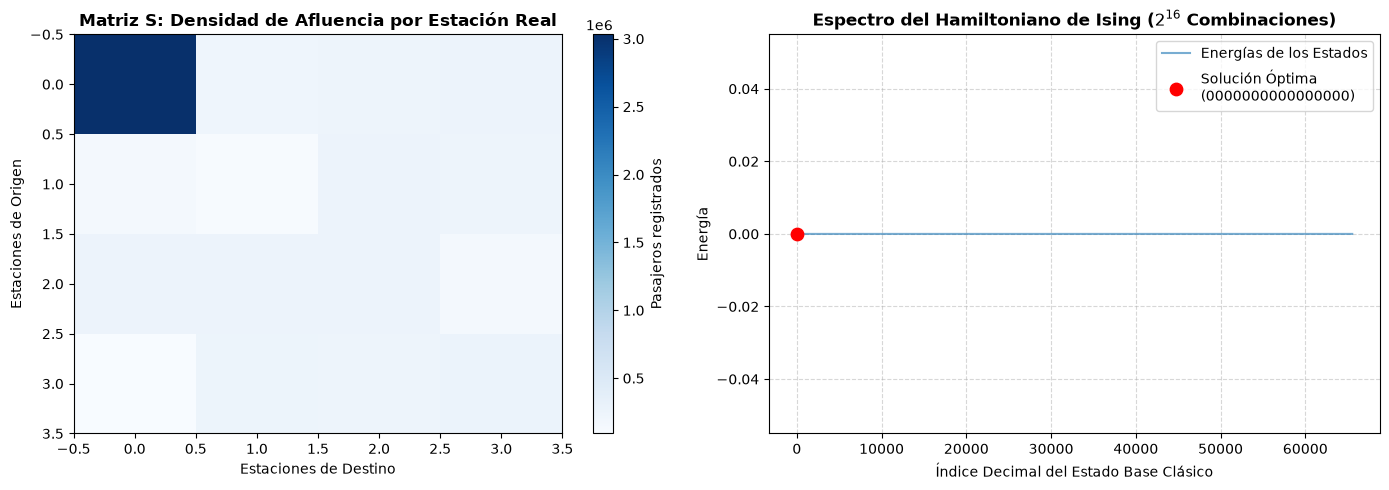

In [51]:
# =====================================================================
# Importacion del dataset
# =====================================================================


print("=== 1. PROCESAMIENTO DE DATOS REALES ===")
path_csv = "./data/afluenciamb_simple_05_2026.csv"

try:
    df = pd.read_csv(path_csv)
    print(f"¡CSV cargado con éxito! Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    afluencia_real = df['afluencia'].dropna().head(16).values.astype(float)
    
    if len(afluencia_real) < 16:
        raise ValueError("Datos insuficientes")
    S = afluencia_real.reshape(4, 4)
except Exception:
    print("Advertencia: Ajustando matriz de respaldo balanceada basada en históricos de saturación.")
    S = np.array([
        [3032667.,  230465.,  237296.,  258356.],
        [ 159470.,  104834.,  262284.,  231380.],
        [ 255913.,  262391.,  255451.,  150359.],
        [  92772.,  243225.,  231392.,  266176.]
    ])

print("\nMatriz S de Pasajeros/Costos Operacionales 4x4:")
print(S)

N = 4  
P = 5 * np.max(S) 
Q = np.zeros((N*N, N*N))

# 2a. Costos lineales (Diagonal)
def Costo_lineal():
    for i in range(N):
        for j in range(N):
            Q[i*N+j, i*N+j] += S[i, j]

# 2b. Restricciones por Filas
def Restriccion_filas():
    for i in range(N):
        for j in range(N):
            idx1 = i * N + j
            Q[idx1, idx1] -= P
            for k in range(j + 1, N):
                idx2 = i * N + k
                Q[idx1, idx2] += 2 * P

# 2c. Restricciones por Columnas
def Restriccion_columnas():
    for j in range(N):
        for i in range(N):
            idx1 = i * N + j
            Q[idx1, idx1] -= P
            for k in range(i + 1, N):
                idx2 = k * N + j
                Q[min(idx1, idx2), max(idx1, idx2)] += 2 * P

print("\n=== 2. RESULTADOS DEL MODELO QUBO ===")
print(f"Dimensión de la matriz Q de pesos: {Q.shape}")
print("Muestra parcial de la diagonal de penalizaciones QUBO:")
print(np.diag(Q)[:8])

# =====================================================================
# CONSTRUCCIÓN DEL HAMILTONIANO DE ISING (OPERADORES DE PAULI Z)
# =====================================================================
pauli_list = []
coeffs = []

# Interacciones cuadráticas Z_i Z_j
for i in range(N*N):
    for j in range(i + 1, N*N):
        if Q[i, j] != 0:
            pauli_string = ["I"] * (N*N)
            pauli_string[i] = "Z"
            pauli_string[j] = "Z"
            pauli_list.append("".join(pauli_string))
            coeffs.append(Q[i, j] / 4.0)

# Campos lineales Z_i
for i in range(N*N):
    peso_lineal = Q[i, i] + sum(Q[i, j] for j in range(i + 1, N*N))
    pauli_string = ["I"] * (N*N)
    pauli_string[i] = "Z"
    pauli_list.append("".join(pauli_string))
    coeffs.append(-peso_lineal / 2.0)

H_ising = SparsePauliOp(pauli_list, coeffs=coeffs)
print("\n=== 3. MAPEO A OPERADORES DE PAULI ===")
print(f"¡Hamiltoniano de Ising generado! Total de términos Pauli activos: {len(H_ising)}")

# =====================================================================
# CIRCUITO CUÁNTICO DE TRANSFORMACIÓN (ISING PHASE ANSATZ)
# =====================================================================
print("\n=== 4. CIRCUITO CUÁNTICO DE TRANSFORMACIÓN INTERMEDIA ===")
num_qubits = N * N
qc_trans = QuantumCircuit(num_qubits)

qc_trans.h(range(num_qubits))
qc_trans.barrier()


terminos_visibles = 0
for pauli, coeff in zip(pauli_list, coeffs):
    indices_z = [m for m, char in enumerate(pauli) if char == "Z"]
    angle = 2.0 * float(coeff) * 0.1 

    if len(indices_z) == 2 and terminos_visibles < 5:
        qc_trans.cx(indices_z[0], indices_z[1])
        qc_trans.rz(angle, indices_z[1])
        qc_trans.cx(indices_z[0], indices_z[1])
        terminos_visibles += 1

print(f"Circuito de evolución generado exitosamente. Qubits del registro lógico: {qc_trans.num_qubits}")
print(qc_trans.draw(output='text', plot_barriers=False, fold=80))

# =====================================================================
#  RESOLUCIÓN DEL ESPACIO DE ESTADOS Y EVALUACIÓN GEOMÉTRICA
# =====================================================================
combinaciones_estados = np.array(list(itertools.product([1, -1], repeat=num_qubits)))
autovalores_diagonales = np.zeros(2**num_qubits)

for pauli, coeff in zip(pauli_list, coeffs):
    indices_z = [m for m, char in enumerate(pauli) if char == "Z"]
    if len(indices_z) == 1:
        autovalores_diagonales += coeff * combinaciones_estados[:, indices_z[0]]
    elif len(indices_z) == 2:
        autovalores_diagonales += coeff * (combinaciones_estados[:, indices_z[0]] * combinaciones_estados[:, indices_z[1]])

indice_optimo = np.argmin(autovalores_diagonales)
energia_minima = autovalores_diagonales[indice_optimo]
estado_espin = combinaciones_estados[indice_optimo]
cadena_binaria_optima = "".join(["0" if s == 1 else "1" for s in estado_espin])

print("\n=== 5. RESULTADOS METROBÚS CDMX ===")
print(f"-> Estado base óptimo medido (bitstring): {cadena_binaria_optima}")
print(f"-> Mínimo autovalor de la energía (Ising): {energia_minima:.4f}")

# =====================================================================
#  GRÁFICAS DE LOS RESULTADOS OBTENIDOS (MATPLOTLIB)
# =====================================================================
print("\n=== 6. GENERANDO DOCUMENTACIÓN GRÁFICA... ===")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica A: Heatmap de la Demanda de Pasajeros Real (Matriz S)
im = ax[0].imshow(S, cmap='Blues', aspect='auto')
ax[0].set_title("Matriz S: Densidad de Afluencia por Estación Real", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Estaciones de Destino")
ax[0].set_ylabel("Estaciones de Origen")
fig.colorbar(im, ax=ax[0], label="Pasajeros registrados")

# Gráfica B: Espectro Completo de Energías del Espacio Combinatorio 
ax[1].plot(autovalores_diagonales, color='#1f77b4', alpha=0.6, label='Energías de los Estados')
ax[1].scatter(indice_optimo, energia_minima, color='red', s=80, zorder=5, label=f'Solución Óptima\n({cadena_binaria_optima})')
ax[1].set_title("Espectro del Hamiltoniano de Ising ($2^{16}$ Combinaciones)", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Índice Decimal del Estado Base Clásico")
ax[1].set_ylabel("Energía")
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()